<a href="https://colab.research.google.com/github/caoyang0428-art/ML-Assignment/blob/main/Assignment_3_Yang_Cao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - Yang Cao

### Task

The task is to respond to questions 2 and 3 of the homework proposed at the end of lecture ML-05, considering only the two top models selected, a linear regression model and a gradient boosting model.

2. Evaluate in dollar terms the predictive performance of the models presented in this example. For instance, you can use the mean (or median) absolute error.

3. Is it better to use the percentage error in the above assessment?

### Preparation

We import the data first.

In [4]:
import pandas as pd
path = 'https://raw.githubusercontent.com/lab30041954/Data/main/'
df = pd.read_csv(path + 'king.csv', index_col=0)
df.head()

,date,zipcode,lat,long,bedrooms,bathrooms,sqft_above,sqft_basement,sqft_lot,floors,waterfront,condition,yr_built,yr_renovated,price
id,,,,,,,,,,,,,,,
7129300520,20141013T000000,98178,47.5112,-122.257,3,1.00,1180,0,5650,1.0,0,3,1955,0,221900
6414100192,20141209T000000,98125,47.7210,-122.319,3,2.25,2170,400,7242,2.0,0,3,1951,1991,538000
5631500400,20150225T000000,98028,47.7379,-122.233,2,1.00,770,0,10000,1.0,0,3,1933,0,180000
2487200875,20141209T000000,98136,47.5208,-122.393,4,3.00,1050,910,5000,1.0,0,5,1965,0,604000
1954400510,20150218T000000,98074,47.6168,-122.045,3,2.00,1680,0,8080,1.0,0,3,1987,0,510000


We rescale the sale price to the thousands, to have simpler numbers.

In [5]:
df['price'] = df['price'] / 1000

### Linear regression model

We will use the following features: all original features except date, price, lat, and long, plus dummy variables generated by one-hot encoding zipcode. This is the configuration for the linear regression model that performed better in the previous analysis."

In [6]:
from sklearn.linear_model import LinearRegression
y = df['price']
X1 = df.drop(columns=['date', 'zipcode', 'lat', 'long', 'price'])
X2 = pd.get_dummies(df['zipcode'])
X = pd.concat([X1, X2], axis=1)
X = X.values

Now, we will train a linear regression model using the prepared feature matrix X and target variable y.

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred = lin_reg.predict(X)

the R-squared value:

In [11]:
round(lin_reg.score(X, y), 3)

0.785

We create the scatter plot to understand the data.

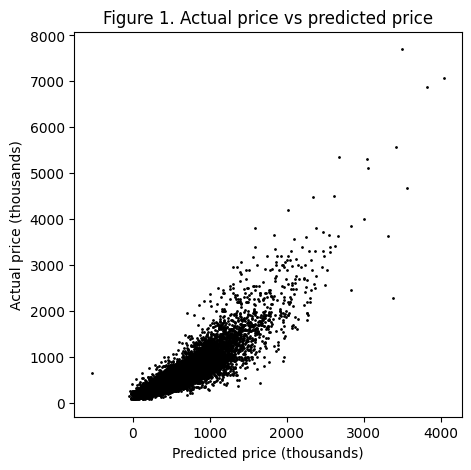

In [14]:
from matplotlib import pyplot as plt
plt.figure(figsize=(5,5))
plt.title('Figure 1. Actual price vs predicted price')
plt.scatter(x=y_pred, y=y, color='black', s=1)
plt.xlabel('Predicted price (thousands)')
plt.ylabel('Actual price (thousands)');

### Gradient boosting model

We try next a gradient boosting approach.

In [15]:
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6)
xgb_reg.fit(X, y)
round(xgb_reg.score(X, y), 3)

0.885

We also create the scatter plot to understand the data.

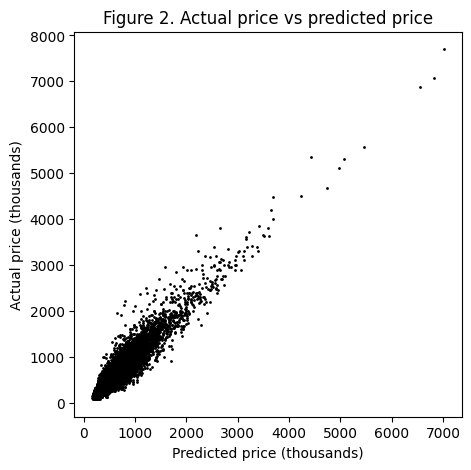

In [16]:
y_pred = xgb_reg.predict(X)
plt.figure(figsize=(5,5))
plt.title('Figure 2. Actual price vs predicted price')
plt.scatter(x=y_pred, y=y, color='black', s=1)
plt.xlabel('Predicted price (thousands)')
plt.ylabel('Actual price (thousands)');

### Calculate MAE


Calculate the Mean Absolute Error (MAE) for the linear regression


In [17]:
from sklearn.metrics import mean_absolute_error

# Re-predict using the linear regression model to ensure y_pred corresponds to lin_reg
# The previous y_pred was overwritten by the XGBoost prediction.
lin_reg_y_pred = lin_reg.predict(X)

mae_linear_regression = mean_absolute_error(y, lin_reg_y_pred)
print(f"Mean Absolute Error for Linear Regression: {mae_linear_regression:.3f} thousand dollars")

Mean Absolute Error for Linear Regression: 103.083 thousand dollars


Calculate the Mean Absolute Error (MAE) for the gradient boosting model



In [18]:
mae_gradient_boosting = mean_absolute_error(y, xgb_reg.predict(X))
print(f"Mean Absolute Error for Gradient Boosting: {mae_gradient_boosting:.3f} thousand dollars")

Mean Absolute Error for Gradient Boosting: 83.816 thousand dollars


### Calculate MAPE


Calculate the Mean Absolute Percentage Error (MAPE) for the linear regression model


In [19]:
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_linear_regression = mean_absolute_percentage_error(y, lin_reg_y_pred)
print(f"Mean Absolute Percentage Error for Linear Regression: {mape_linear_regression:.3f}%")

Mean Absolute Percentage Error for Linear Regression: 20.826%


Calculate the Mean Absolute Percentage Error (MAPE) for the gradient boosting model



In [20]:
mape_gradient_boosting = mean_absolute_percentage_error(y, xgb_reg.predict(X))
print(f"Mean Absolute Percentage Error for Gradient Boosting: {mape_gradient_boosting:.3f}%")

Mean Absolute Percentage Error for Gradient Boosting: 17.697%


### Summary and Discussion of Results



#### Question 2: Evaluate in dollar terms the predictive performance of the models presented in this example. For instance, you can use the mean (or median) absolute error.

**Linear Regression Model:**
*   **Mean Absolute Error (MAE):** `103.083 thousand dollars`

**Gradient Boosting Model:**
*   **Mean Absolute Error (MAE):** `83.816 thousand dollars`

In dollar terms, the **Gradient Boosting Model** shows a significantly better predictive performance with an MAE of approximately \$83,816, compared to the Linear Regression Model's MAE of approximately \$103,083. This means, on average, the gradient boosting model's predictions are closer to the actual house prices by about \$19,267 less than the linear regression model.

#### Question 3: Is it better to use the percentage error in the above assessment?

**Linear Regression Model:**
*   **Mean Absolute Percentage Error (MAPE):** `20.826%`

**Gradient Boosting Model:**
*   **Mean Absolute Percentage Error (MAPE):** `17.697%`

Using percentage error (MAPE) provides a relative measure of accuracy, which can be particularly useful when dealing with a wide range of values in the target variable (house prices). For instance, an error of \$100,000 might be very significant for a \$200,000 house but less so for a \$1,000,000 house. Percentage error normalizes this by expressing the error as a proportion of the actual value.

In this case, the **Gradient Boosting Model** also performs better in percentage terms, with a MAPE of approximately 17.697%, compared to the Linear Regression Model's MAPE of approximately 20.826%. This indicates that, on average, the gradient boosting model's predictions are about 3.129 percentage points closer to the actual price relative to the house's value.

**Conclusion:**
While both dollar terms (MAE) and percentage terms (MAPE) are valuable for assessment, using **percentage error (MAPE) is generally better for comparing models on a dataset with varying scales of values**, as it provides a more robust and scale-independent understanding of predictive accuracy. In this scenario, both metrics consistently show that the Gradient Boosting Model outperforms the Linear Regression Model.